# Proyecto 2 — Resultados
## Reconocimiento de *fingerspelling* en ASL a partir de landmarks de MediaPipe

**CC3084 Data Science · Reto 15: Google – American Sign Language Fingerspelling Recognition**

Este notebook es el *pipeline* maestro de la fase de resultados. Se ejecuta de principio a fin y produce todo lo que usan el informe y la aplicación:

| Parte | Contenido | Salida |
|---|---|---|
| I | Preparación de datos: partición por participante, limpieza y extracción de características | `features.npy`, `masks.npy`, `index.csv`, secuencias de muestra para la app |
| II | Entrenamiento inicial de BiGRU + CTC | `m1_bigru_ctc.pt`, `m1_history.csv` |
| III | Evaluación de validación del primer modelo | `metrics.json` |

### Cómo ejecutarlo
- **Local:** usa los parquets disponibles en `data/train_landmarks/` (para desarrollo basta uno).
- **Kaggle:** se sube este mismo notebook con la competencia `asl-fingerspelling` como fuente de datos. El notebook detecta el entorno, clona el repositorio para importar `src/` y procesa los parquets montados en `/kaggle/input`, sin descargar nada.

La única configuración a tocar está en la celda **Configuración**.

## 0. Entorno y configuración

In [1]:
import os
import sys
import glob
import json
import time
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq

ON_KAGGLE = os.path.exists("/kaggle/input")
REPO_URL = "https://github.com/jcdiegolopez/DS-PR02.git"

if ON_KAGGLE:
    ROOT = "/tmp/DS-PR02"  # fuera de /kaggle/working para no mezclar el repo con la salida
    if not os.path.exists(ROOT):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, ROOT], check=True)
else:
    ROOT = os.path.abspath("..") if os.path.exists("../src") else os.path.abspath(".")
sys.path.insert(0, ROOT)

from src.data_loader import get_landmark_columns
from src.preprocessing import (FEATURE_COLUMNS, N_FEATURES, MIN_COVERAGE, MAX_GAP,
                               preprocess_sequence, sequence_coverage)

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"Entorno: {'Kaggle' if ON_KAGGLE else 'local'} | raíz del proyecto: {ROOT}")
print(f"Características por frame: {N_FEATURES}")

Entorno: local | raíz del proyecto: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-PR02
Características por frame: 80


### Configuración
- `N_FILES`: cuántos parquets procesar (`None` = todos los disponibles). En local solo hay uno; en Kaggle se puede escalar a los 68.
- `SPLIT_FRACTIONS`: proporción de **participantes** (no de secuencias) en entrenamiento, validación y prueba.
- `N_APP_SAMPLES`: secuencias crudas del conjunto de prueba que se exportan para la aplicación.

In [2]:
SEED = 42
N_FILES = None
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
N_APP_SAMPLES = 30

if ON_KAGGLE:
    COMP_DIR = os.path.dirname(glob.glob("/kaggle/input/**/train.csv", recursive=True)[0])
    OUTPUT_DIR = "/kaggle/working/processed"
    APP_SAMPLES_DIR = "/kaggle/working/sample_sequences"
else:
    COMP_DIR = os.path.join(ROOT, "data")
    OUTPUT_DIR = os.path.join(ROOT, "data", "processed")
    APP_SAMPLES_DIR = os.path.join(ROOT, "app", "sample_sequences")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Datos de la competencia:", COMP_DIR)
print("Salida:", OUTPUT_DIR)

Datos de la competencia: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-PR02\data
Salida: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-PR02\data\processed


# Parte I — Preparación de datos

Esta parte convierte los parquets crudos (1,629 columnas por frame) en una representación compacta lista para modelar. Aplica el *pipeline* de limpieza diseñado y validado en el análisis exploratorio, implementado en `src/preprocessing.py` para que la aplicación use exactamente el mismo código.

## 1. Partición por participante

En el EDA se identificó una variabilidad inter-firmante notable (velocidad, lateralidad, estilo). Si un mismo participante apareciera en entrenamiento y en prueba, el modelo podría memorizar su estilo y la evaluación sobrestimaría su desempeño. Por eso la partición se hace **por `participant_id`**: el conjunto de prueba contiene solo firmantes que el modelo nunca vio, que es lo que la aplicación presenta como "datos nuevos".

La partición se define sobre el catálogo completo (`train.csv`), así que es la misma sin importar cuántos parquets se procesen.

In [3]:
meta = pd.read_csv(os.path.join(COMP_DIR, "train.csv"))

rng = np.random.default_rng(SEED)
participants = np.array(sorted(meta["participant_id"].unique()))
rng.shuffle(participants)

n_train = int(round(len(participants) * SPLIT_FRACTIONS["train"]))
n_val = int(round(len(participants) * SPLIT_FRACTIONS["val"]))
split_of = {p: "train" for p in participants[:n_train]}
split_of.update({p: "val" for p in participants[n_train:n_train + n_val]})
split_of.update({p: "test" for p in participants[n_train + n_val:]})
meta["split"] = meta["participant_id"].map(split_of)

resumen_split = meta.groupby("split").agg(
    participantes=("participant_id", "nunique"),
    secuencias=("sequence_id", "size"),
    longitud_media_frase=("phrase", lambda s: s.str.len().mean()),
).reindex(["train", "val", "test"])
resumen_split["% secuencias"] = (resumen_split["secuencias"] / len(meta) * 100).round(1)
assert meta.groupby("participant_id")["split"].nunique().max() == 1, "Un participante quedó en dos conjuntos"
resumen_split.round(2)

,participantes,secuencias,longitud_media_frase,% secuencias
split,,,,
train,75,54377,17.78,80.9
val,9,6894,17.84,10.3
test,10,5937,18.00,8.8


## 2. Limpieza y extracción de características

Para cada secuencia, `preprocess_sequence` aplica los pasos del EDA: selección de la mano activa (reflejando a los zurdos), invalidación de *outliers* biomecánicos, recorte de extremos, interpolación solo en huecos de hasta 5 frames y normalización. Devuelve:

- **Características** `[T, N_FEATURES]`: mano activa normalizada (63), posición de la muñeca respecto al cuerpo (2), pose de hombros, codos, muñecas y nariz (14) y presencia de la otra mano (1).
- **Máscara** `[T]`: `True` en los frames con dato observado o recuperado. Los demás se rellenan con 0 solo para que el tensor sea numérico, y el modelo los ignora.

Solo se leen del parquet las columnas necesarias (141 de 1,631), lo que hace viable procesar el corpus completo en Kaggle.

**Sobre el descarte:** el criterio del EDA (cobertura ≥ 50%) no se aplica aquí. Se guarda la cobertura de cada secuencia y el umbral se decide en el entrenamiento, porque descartar cerca del 29% de los datos es costoso y conviene medir su efecto.

In [4]:
landmark_files = sorted(glob.glob(os.path.join(COMP_DIR, "train_landmarks", "*.parquet")))
if N_FILES is not None:
    landmark_files = landmark_files[:N_FILES]
print(f"Parquets a procesar: {len(landmark_files)}")

meta_by_id = meta.set_index("sequence_id")
feature_chunks, mask_chunks, index_rows = [], [], []
offset = 0
t0 = time.time()

for i, path in enumerate(landmark_files, 1):
    frames = pq.read_table(path, columns=["sequence_id"] + FEATURE_COLUMNS).to_pandas()
    if "sequence_id" not in frames.columns:
        frames = frames.reset_index()
    for sequence_id, raw in frames.groupby("sequence_id", sort=False):
        if sequence_id not in meta_by_id.index:
            continue
        features, mask = preprocess_sequence(raw)
        row = meta_by_id.loc[sequence_id]
        index_rows.append({
            "sequence_id": int(sequence_id),
            "participant_id": int(row["participant_id"]),
            "phrase": row["phrase"],
            "split": row["split"],
            "file_id": int(row["file_id"]),
            "raw_frames": len(raw),
            "offset": offset,
            "length": len(mask),
            "coverage": sequence_coverage(mask),
        })
        feature_chunks.append(features.astype(np.float16))
        mask_chunks.append(mask)
        offset += len(mask)
    print(f"[{i}/{len(landmark_files)}] {os.path.basename(path)} · secuencias acumuladas: {len(index_rows):,} · {time.time() - t0:,.0f} s")

features_all = np.concatenate(feature_chunks)
masks_all = np.concatenate(mask_chunks)
index = pd.DataFrame(index_rows)
index["phrase_length"] = index["phrase"].str.len()
print(f"\nFrames totales: {len(features_all):,} · memoria de características: {features_all.nbytes / 1024**2:,.1f} MB")

Parquets a procesar: 1


[1/1] 5414471.parquet · secuencias acumuladas: 1,000 · 2 s

Frames totales: 160,770 · memoria de características: 24.5 MB


### 2.1 Almacenamiento

Las secuencias tienen longitudes distintas, así que se guardan concatenadas en un solo arreglo y el índice registra dónde empieza (`offset`) y cuánto mide (`length`) cada una. La secuencia `k` se recupera con `features[offset:offset + length]`. Las características se guardan en `float16`, suficiente para coordenadas normalizadas y la mitad de memoria que `float32`.

In [5]:
np.save(os.path.join(OUTPUT_DIR, "features.npy"), features_all)
np.save(os.path.join(OUTPUT_DIR, "masks.npy"), masks_all)
index.to_csv(os.path.join(OUTPUT_DIR, "index.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump({
        "seed": SEED, "split_fractions": SPLIT_FRACTIONS, "n_files": len(landmark_files),
        "n_features": N_FEATURES, "max_gap": MAX_GAP, "min_coverage_eda": MIN_COVERAGE,
        "feature_columns": FEATURE_COLUMNS,
    }, f, indent=2)

def load_sequence_features(k: int):
    # Recupera las características y la máscara de la fila k del índice
    r = index.iloc[k]
    return features_all[r.offset:r.offset + r.length], masks_all[r.offset:r.offset + r.length]

f0, m0 = load_sequence_features(0)
print(f"Ejemplo: '{index.phrase.iloc[0]}' -> características {f0.shape}, máscara {m0.shape}")
print("Archivos guardados:", sorted(os.listdir(OUTPUT_DIR)))

Ejemplo: '3 creekhouse' -> características (123, 80), máscara (123,)
Archivos guardados: ['config.json', 'features.npy', 'index.csv', 'masks.npy']


## 3. Diagnóstico del conjunto preparado

Antes de modelar se verifican tres cosas:
1. Que la partición por participante produzca conjuntos comparables.
2. Cuántas secuencias sobreviven según el umbral de cobertura.
3. Que haya **suficientes frames por carácter** para la pérdida CTC. CTC exige que la secuencia de entrada tenga al menos tantos pasos como caracteres en la frase (más uno por cada letra repetida consecutiva, como en *"ll"*). Si no se cumple, esa secuencia no se puede entrenar.

In [6]:
def ctc_min_length(phrase: str) -> int:
    # Longitud mínima de entrada para CTC: caracteres + repeticiones consecutivas
    return len(phrase) + sum(a == b for a, b in zip(phrase, phrase[1:]))

index["ctc_min_length"] = index["phrase"].map(ctc_min_length)
index["frames_per_char"] = index["length"] / index["phrase_length"].clip(lower=1)
index["ctc_feasible"] = index["length"] >= index["ctc_min_length"]

thresholds = [0.0, 0.2, 0.3, 0.4, MIN_COVERAGE]
retention = pd.DataFrame({
    f"cobertura ≥ {t:.0%}": index[index["coverage"] >= t].groupby("split").size()
    for t in thresholds
}).reindex(["train", "val", "test"])

print("Secuencias procesadas por conjunto:")
display(index.groupby("split").agg(
    secuencias=("sequence_id", "size"), participantes=("participant_id", "nunique"),
    frames_medios=("length", "mean"), cobertura_media=("coverage", "mean"),
    ctc_factible=("ctc_feasible", "mean"),
).reindex(["train", "val", "test"]).round(3))
print("\nSecuencias retenidas según el umbral de cobertura:")
display(retention)

Secuencias procesadas por conjunto:


,secuencias,participantes,frames_medios,cobertura_media,ctc_factible
split,,,,,
train,803,73,157.537,0.680,0.961
val,106,9,178.462,0.594,0.981
test,91,10,168.692,0.714,0.989



Secuencias retenidas según el umbral de cobertura:


,cobertura ≥ 0%,cobertura ≥ 20%,cobertura ≥ 30%,cobertura ≥ 40%,cobertura ≥ 50%
split,,,,,
train,803,730,678,625,581
val,106,89,76,69,62
test,91,85,80,79,70


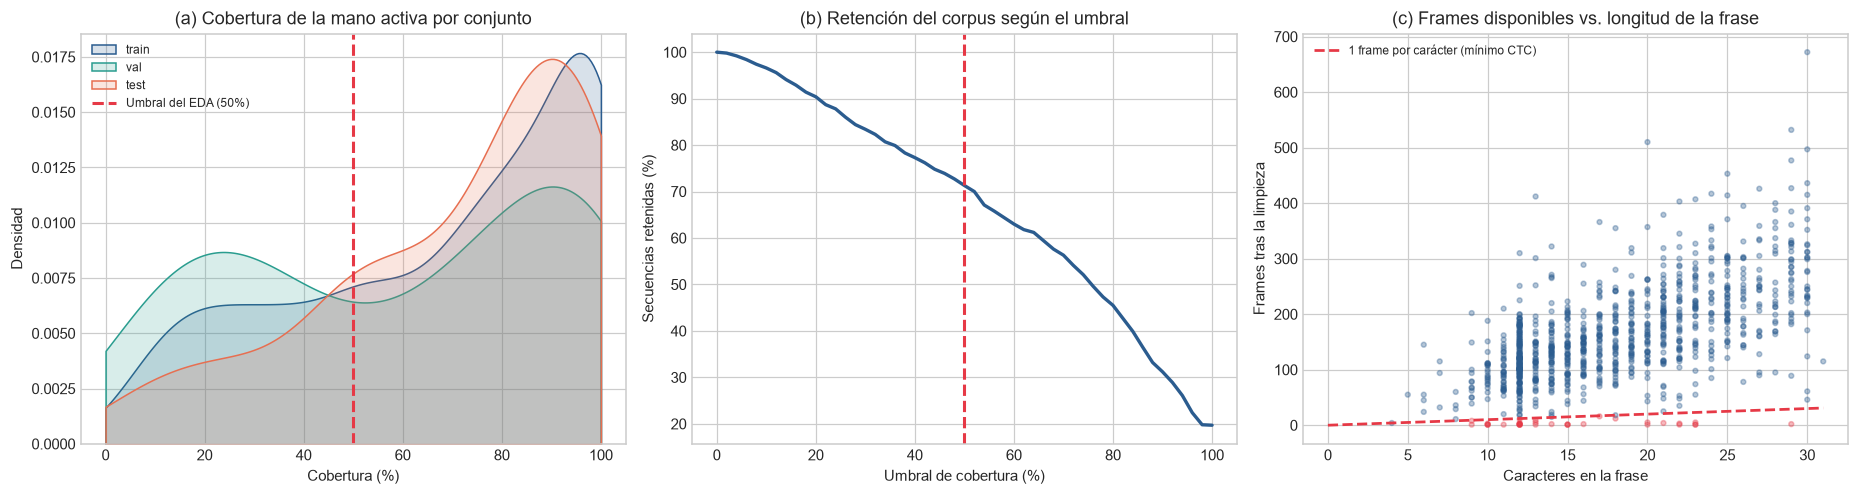

Secuencias no factibles para CTC: 34 (3.4%)
Mediana de frames por carácter: 8.8


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
split_colors = {"train": "#2b5c8f", "val": "#2a9d8f", "test": "#e76f51"}

for split, color in split_colors.items():
    sns.kdeplot(index.loc[index.split == split, "coverage"] * 100, ax=axes[0],
                color=color, label=split, fill=True, alpha=0.18, clip=(0, 100), warn_singular=False)
axes[0].axvline(MIN_COVERAGE * 100, color="#e63946", linestyle="--", linewidth=2, label="Umbral del EDA (50%)")
axes[0].set(title="(a) Cobertura de la mano activa por conjunto", xlabel="Cobertura (%)", ylabel="Densidad")
axes[0].legend(fontsize=8)

curve_t = np.linspace(0, 1, 51)
axes[1].plot(curve_t * 100, [(index["coverage"] >= t).mean() * 100 for t in curve_t], color="#2b5c8f", linewidth=2.2)
axes[1].axvline(MIN_COVERAGE * 100, color="#e63946", linestyle="--", linewidth=2)
axes[1].set(title="(b) Retención del corpus según el umbral", xlabel="Umbral de cobertura (%)", ylabel="Secuencias retenidas (%)")

axes[2].scatter(index["phrase_length"], index["length"], s=10, alpha=0.35,
                c=np.where(index["ctc_feasible"], "#2b5c8f", "#e63946"))
max_len = index["phrase_length"].max()
axes[2].plot([0, max_len], [0, max_len], color="#e63946", linestyle="--", linewidth=1.8, label="1 frame por carácter (mínimo CTC)")
axes[2].set(title="(c) Frames disponibles vs. longitud de la frase", xlabel="Caracteres en la frase", ylabel="Frames tras la limpieza")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Secuencias no factibles para CTC: {(~index['ctc_feasible']).sum():,} ({(~index['ctc_feasible']).mean():.1%})")
print(f"Mediana de frames por carácter: {index['frames_per_char'].median():.1f}")

## 4. Secuencias de muestra para la aplicación

La aplicación recibe secuencias **crudas** en el formato original de Kaggle y aplica el preprocesamiento de forma invisible para el usuario. Se exportan secuencias solo del conjunto de **prueba**, de participantes que el modelo no vio durante el entrenamiento.

Se conservan todas las columnas de manos y pose sin procesar. La malla facial se omite porque representa el 86% del volumen de cada archivo (cada secuencia pasaría de ~0.5 MB a ~2–4 MB) y el modelo no la usa. La aplicación acepta igualmente archivos con la cara incluida.

In [8]:
os.makedirs(APP_SAMPLES_DIR, exist_ok=True)
raw_columns = ["sequence_id", "frame"] + get_landmark_columns(kinds=["left_hand", "pose", "right_hand"])

candidates = index[(index.split == "test") & index.ctc_feasible]
samples = candidates.sample(min(N_APP_SAMPLES, len(candidates)), random_state=SEED)

manifest = []
for file_id, group in samples.groupby("file_id"):
    path = os.path.join(COMP_DIR, "train_landmarks", f"{file_id}.parquet")
    ids = [int(s) for s in group.sequence_id]
    raw = pq.read_table(path, columns=raw_columns, filters=[("sequence_id", "in", ids)]).to_pandas()
    if "sequence_id" not in raw.columns:
        raw = raw.reset_index()
    for sequence_id, seq in raw.groupby("sequence_id"):
        name = f"seq_{sequence_id}.parquet"
        seq.sort_values("frame").to_parquet(os.path.join(APP_SAMPLES_DIR, name), index=False, compression="zstd")
        row = group.set_index("sequence_id").loc[sequence_id]
        manifest.append({"file": name, "sequence_id": int(sequence_id), "participant_id": int(row.participant_id),
                         "phrase": row.phrase, "frames": len(seq), "coverage": round(float(row.coverage), 3)})

manifest = pd.DataFrame(manifest).sort_values("sequence_id")
manifest.to_csv(os.path.join(APP_SAMPLES_DIR, "manifest.csv"), index=False)
size_mb = sum(os.path.getsize(os.path.join(APP_SAMPLES_DIR, f)) for f in os.listdir(APP_SAMPLES_DIR)) / 1024**2
print(f"Secuencias exportadas: {len(manifest)} · tamaño total: {size_mb:.1f} MB")
manifest.head(10)

Secuencias exportadas: 30 · tamaño total: 7.0 MB


,file,sequence_id,participant_id,phrase,frames,coverage
0,seq_1817216847.parquet,1817216847,93,271097 bayshore boulevard,453,0.819
1,seq_1817631401.parquet,1817631401,169,1600 fire water,91,0.681
2,seq_1819517369.parquet,1819517369,24,+20-4703-88149,133,1.000
3,seq_1819539423.parquet,1819539423,141,fysiotherapiedewaard.nl/585685,312,0.811
4,seq_1820470531.parquet,1820470531,169,hinata4753/udaurajaya,176,0.960
5,seq_1822709654.parquet,1822709654,141,+245-67-36-755,131,0.870
6,seq_1823491509.parquet,1823491509,15,818-534-0702,193,1.000
7,seq_1824112545.parquet,1824112545,24,607-290-9284,117,0.846
8,seq_1825130335.parquet,1825130335,24,522-522-1486,101,0.723
9,seq_1827299597.parquet,1827299597,168,https://www.e-karma.pl,224,0.486


## 5. Verificación de consistencia entre entrenamiento y aplicación

Se comprueba que una secuencia exportada, procesada como lo hará la aplicación (leyendo el archivo crudo completo), produzca exactamente las mismas características que se guardaron para el modelo.

In [9]:
check = manifest.iloc[0]
raw_app = pd.read_parquet(os.path.join(APP_SAMPLES_DIR, check.file))
features_app, mask_app = preprocess_sequence(raw_app)

k = index.index[index.sequence_id == check.sequence_id][0]
features_saved, mask_saved = load_sequence_features(k)

assert np.array_equal(mask_app, mask_saved)
max_diff = np.abs(features_app.astype(np.float16).astype(np.float32) - features_saved.astype(np.float32)).max()
assert max_diff == 0, max_diff
print(f"OK: la secuencia {check.sequence_id} ('{check.phrase}') produce las mismas características en la app y en el conjunto de entrenamiento.")

OK: la secuencia 1817216847 ('271097 bayshore boulevard') produce las mismas características en la app y en el conjunto de entrenamiento.


## 6. Hallazgos de la Parte I

Las cifras de esta sección corresponden a la ejecución sobre el **corpus completo en Kaggle** (68 parquets). Las salidas de las celdas pueden corresponder a una ejecución local con un solo parquet.

1. **El corpus completo es procesable con recursos modestos.** Las 67,208 secuencias (10.6 millones de frames) se limpiaron en unos 9 minutos de CPU leyendo solo 141 de las 1,631 columnas. El resultado ocupa 1.6 GB en `float16`, frente a los ~190 GB originales.
2. **La partición por participante es estable y comparable en texto:** 75 participantes y 54,377 secuencias en entrenamiento, 9 y 6,894 en validación, 10 y 5,937 en prueba. La longitud media de las frases es prácticamente igual en los tres conjuntos (17.8–18.0 caracteres).
3. **La calidad de la señal depende del firmante, no solo de la secuencia.** La cobertura media de la mano activa por participante va de 33% a 94%. Con solo 9 participantes, el conjunto de validación quedó con una cobertura media menor (59%) que entrenamiento (69%) y prueba (70%). Por lo tanto, **la validación es algo más difícil que la prueba**, y hay que considerarlo al comparar sus métricas.
4. **El umbral de descarte del EDA es costoso.** Exigir 50% de cobertura conserva el 71.1% del corpus; con 20% se conserva el 90.5%. Dado que el modelo recibe una máscara de validez, el umbral se trata como hiperparámetro de la Parte II en lugar de fijarlo aquí.
5. **CTC es viable para casi todo el corpus.** La mediana es de 8.8 frames por carácter, holgada respecto al mínimo de CTC. Solo el 3.8% de las secuencias (2,527) tiene menos frames que los que exige su frase y debe excluirse del entrenamiento.
6. **El preprocesamiento es idéntico en el entrenamiento y en la aplicación**, verificado en local y en Kaggle: una secuencia cruda exportada produce exactamente las mismas características que las guardadas para el modelo.

---

# Parte II — Modelos

*(En construcción.)*

# Parte II — Primer modelo: BiGRU + CTC

El vocabulario oficial se desplaza una posición para reservar el índice 0 al *blank* de CTC. Se descartan los frames inválidos indicados por `masks.npy` y las secuencias que no tienen frames suficientes para representar el texto. Los lotes usan padding dinámico y longitudes reales. Solo `train` actualiza los pesos; `val` selecciona el checkpoint. El conjunto `test` se reserva para la evaluación final.

Esta celda requiere el conjunto procesado de la Parte I y PyTorch (`pip install -r requirements.txt`). En Kaggle se usa la GPU disponible. La ejecución completa puede tardar varias horas según el número de parquets.


In [ ]:
from src.train import run_training

MODEL_DIR = "/kaggle/working/models" if ON_KAGGLE else os.path.join(ROOT, "models")
M1_EPOCHS = 8
M1_BATCH_SIZE = 16

m1_metrics = run_training(
    OUTPUT_DIR, MODEL_DIR, epochs=M1_EPOCHS, batch_size=M1_BATCH_SIZE,
    min_coverage=MIN_COVERAGE, seed=SEED,
)
print("Checkpoint:", os.path.join(MODEL_DIR, "m1_bigru_ctc.pt"))
print("Secuencias de entrenamiento:", m1_metrics["train_sequences"])
print("Mejor época:", m1_metrics["best_epoch"])


# Parte III — Evaluación de validación

Las métricas corresponden al mejor checkpoint de M1 sobre `val`. La distancia de edición normalizada es el promedio por frase; CER agrega las ediciones de todos los caracteres. Se registran además coincidencia exacta, errores por tipo de carácter, latencia y número de parámetros. `metrics.json` queda disponible para la aplicación. El conjunto `test` no se consulta aquí.


In [ ]:
m1_summary = pd.Series({
    "Distancia de edición normalizada": m1_metrics["normalized_edit_distance"],
    "CER": m1_metrics["cer"],
    "Coincidencia exacta": m1_metrics["exact_match"],
    "Tiempo de inferencia (ms/secuencia)": m1_metrics["inference_ms_per_sequence"],
    "Parámetros": m1_metrics["parameters"],
})
display(m1_summary.to_frame("Validación M1"))
display(pd.DataFrame(m1_metrics["by_character_type"]).T)

history = pd.read_csv(os.path.join(MODEL_DIR, "m1_history.csv"))
ax = history.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", figsize=(8, 4))
ax.set(xlabel="Época", ylabel="Pérdida CTC", title="Entrenamiento y validación de M1")
plt.show()


### Resultado de referencia de M1

Con las salidas procesadas de los 68 parquets de Kaggle se entrenó M1 en una GPU local durante ocho épocas. Se usaron 37 366 secuencias de entrenamiento y 3 857 de validación. El mejor checkpoint fue el de la época 8: pérdida CTC de validación **0,999**, distancia de edición normalizada **0,2435**, CER **0,2425** y coincidencia exacta **13,12 %**. El modelo tiene **473 405 parámetros**. `models/metrics.json` conserva las cifras exactas y el desglose por tipo de carácter.

La primera época se recuperó desde un checkpoint que solo tenía pesos; al reanudar se reinició AdamW. El historial tiene su pérdida de validación, pero no su pérdida de entrenamiento. El conjunto `test` permanece sin evaluar.